In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from astropy.table import Table, vstack,hstack
import numpy.ma as ma
import sys
sys.path.insert(1, '/Users/nityaravi/Documents/Github/RotationCurves/ellipticals')
from elliptical_plottingFunctions import *
from IO_data import *
from elliptical_stellar_mass import calc_mass_curve
from elliptical_stellar_mass_functions import exponential_disk, exponential_sphere, exponential_sphere_disk

In [2]:
#master_table_fn = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/output_files/DR17/CURRENT_MASTER_TABLE/Elliptical_StelVelDispDAPMeanSigma_Mvir_smoothness_lt_2_dipole_vflag_comoving_mratio.fits'
master_table_fn = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/output_files/DR17/CURRENT_MASTER_TABLE/Elliptical_sphdisk_refitspirals_v4.fits'

master_table = Table.read(master_table_fn)
master_table[:5]

plate,ifudsgn,plateifu,mangaid,versdrp2,versdrp3,verscore,versutil,versprim,platetyp,srvymode,objra,objdec,ifuglon,ifuglat,ifura,ifudec,ebvgal,nexp,exptime,drp3qual,bluesn2,redsn2,harname,frlplug,cartid,designid,cenra,cendec,airmsmin,airmsmed,airmsmax,seemin,seemed,seemax,transmin,transmed,transmax,mjdmin,mjdmed,mjdmax,gfwhm,rfwhm,ifwhm,zfwhm,mngtarg1,mngtarg2,mngtarg3,catidnum,plttarg,manga_tileid,nsa_iauname,ifudesignsize,ifutargetsize,ifudesignwrongsize,z,zmin,zmax,szmin,szmax,ezmin,ezmax,probs,pweight,psweight,psrweight,sweight,srweight,eweight,esweight,esrweight,nsa_field,nsa_run,nsa_camcol,nsa_version,nsa_nsaid,nsa_nsaid_v1b,nsa_z,nsa_zdist,nsa_sersic_absmag,nsa_elpetro_absmag,nsa_elpetro_amivar,nsa_sersic_mass,nsa_elpetro_mass,nsa_elpetro_ba,nsa_elpetro_phi,nsa_extinction,nsa_elpetro_th50_r,nsa_petro_th50,nsa_petro_flux,nsa_petro_flux_ivar,nsa_elpetro_flux,nsa_elpetro_flux_ivar,nsa_sersic_ba,nsa_sersic_n,nsa_sersic_phi,nsa_sersic_th50,nsa_sersic_flux,nsa_sersic_flux_ivar,smoothness_score,nsa_elpetro_th90,v_sys,v_sys_err,ba,ba_err,x0,x0_err,y0,y0_err,phi,phi_err,v_max,v_max_err,r_turn,r_turn_err,chi2,alpha,alpha_err,Rmax,M,M_err,fit_flag,Sigma_disk,Sigma_disk_err,R_disk,R_disk_err,rho_bulge,rho_bulge_err,R_bulge,R_bulge_err,M90_disk,M90_disk_err,M_disk,M_disk_err,chi2_disk,logHI,logHIlim,WF50,WF50_err,DL_ttype,vis_tidal,b,b_err,M_R90,M_R90_err,fit_function,A_g,A_r,logH2,R90_kpc,v_3p5,v_3p5_err,NSA_plate,NSA_fiberID,NSA_MJD,logH2_CG,logH2_CG_err,logH2_M,Z,Z_err,M_Z,M_Z_err,grad_Z,grad_Z_err,Z_0,Z_0_err,SFR,sSFR,SFR_err,sSFR_err,Flux_OII_3726,Flux_OII_3726_Err,Flux_OII_3728,Flux_OII_3728_Err,Flux_OIII_4958,Flux_OIII_4958_Err,Flux_OIII_5006,Flux_OIII_5006_Err,Flux_NII_6547,Flux_NII_6547_Err,Flux_NII_6583,Flux_NII_6583_Err,Flux_Ha_6562,Flux_Ha_6562_Err,Flux_Hb_4861,Flux_Hb_4861_Err,CMD_class,rabsmag_NSA,param_H2,param_H2_err,Z_map,Z_err_map,M_Z_map,M_Z_err_map,logHI_R90,Mvir,Mvir_err,star_sigma,star_sigma_err,dipole_moment,Rgal,vflag_VF,Mstar_HI_R90,Mstar_HI_3p5R90,nsa_elpetro_log_mass,Mstar_Mtot_R90,MstarHI_Mtot_R90,nsa_Mstar_Mtot,rabsmag,param_H2_R90,logHe,Mvis_R90,Mvis_Mtot_R90,sphd_rho_c,sphd_rho_c_err,sphd_R_scale,sphd_R_scale_err,sphd_Sigma_d,sphd_Sigma_d_err,sphd_R_d,sphd_R_d_err,sphd_M_star,sphd_M_star_err,sphd_chi2,mhq_R_scale,mhq_R_scale_err,mhq_M_star,mhq_M_star_err,mhq_gamma,mhq_gamma_err,mhq_chi2,hq_R_scale,hq_R_scale_err,hq_M_star,hq_M_star_err,hq_chi2,sph_rho_c,sph_rho_c_err,sph_R_scale,sph_R_scale_err,sph_M_star,sph_M_star_err,sph_chi2,sum_M_star,sum_M_star_err,Mvir2,Mvir2_err,star_sigma2,star_sigma2_err,e_Mstar_R90
int64,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,float64,float64,float64,float64,float64,float64,float64,int64,float64,int64,float64,float64,bytes53,int64,bytes32,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,int64,int64,int64,int64,bytes32,int64,bytes19,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,bytes6,int64,int64,float64,float64,float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64,float64,float64[7],float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64[7],float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64

In [3]:
master_table_dict = {}
for i in range(len(master_table)):
    master_table_dict[master_table['plateifu'][i]] = i

In [4]:
PIPE3D_FOLDER = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/Pipe3D/'
DATA_FOLDER = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/'
VEL_FOLDER = DATA_FOLDER + 'DR17/'


matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['savefig.dpi'] = 300

In [5]:
plot_dir = '/Users/nityaravi/Documents/Research/RotationCurves/aas_poster_25/'

In [6]:
ellipticals = master_table[master_table['Mvir'] > 0]
ellipticals = ellipticals[ellipticals['sphd_M_star'] > 0]
spirals = master_table[master_table['v_max'] > 0]
spirals = spirals[spirals['M90_disk'] > 0]
spirals = spirals[spirals['alpha'] <= 99]
spirals = spirals[spirals['v_max_err']/spirals['v_max'] <= 2]
v90 = spirals['v_max'] * spirals['R90_kpc'] / (spirals['r_turn']**spirals['alpha'] + spirals['R90_kpc']**spirals['alpha'])**(1/spirals['alpha'])
all_mass_spirals = spirals[np.logical_and(v90 > 10, v90 < 1000)]
spirals = all_mass_spirals[all_mass_spirals['M90_disk']>9]

## virial thm

In [7]:
pipe3d_maps = extract_Pipe3d_data(PIPE3D_FOLDER, '8319-1902', ['sMass'])
dap_maps = extract_data(VEL_FOLDER, '8319-1902', ['star_sigma'])

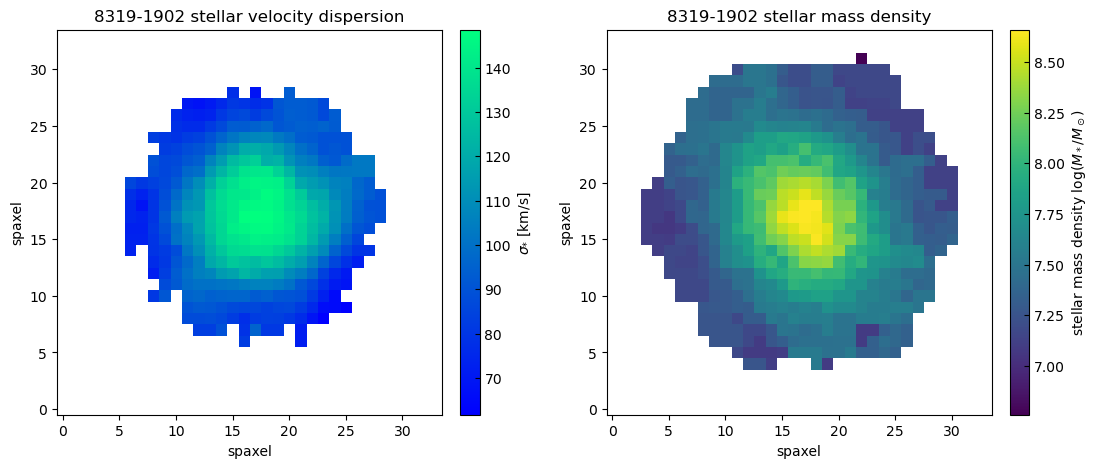

In [8]:
fig, ax = plt.subplots(1,2, figsize=(13,5))
im = ax[0].imshow(ma.array(dap_maps['star_sigma'], mask=dap_maps['star_sigma_mask']), cmap='winter')
# fig.colorbar(c, cax=ax[0])

cbar = plt.colorbar( im, ax=ax[0], fraction=0.046, pad=0.04)
cbar.ax.tick_params( direction='in')
cbar.set_label(r'$\sigma_{*}$ [km/s]') 


ax[0].invert_yaxis()
im2 = ax[1].imshow(pipe3d_maps['sMass_density'])
ax[1].invert_yaxis()
ax[0].set_xlabel('spaxel')
ax[0].set_ylabel('spaxel')
ax[1].set_xlabel('spaxel')
ax[1].set_ylabel('spaxel')
ax[0].set_title('8319-1902 stellar velocity dispersion')
ax[1].set_title('8319-1902 stellar mass density')

cbar = plt.colorbar( im2, ax=ax[1], fraction=0.046, pad=0.04)
cbar.ax.tick_params( direction='in')

cbar.set_label(r'stellar mass density $\log(M_*/M_\odot)$')

plt.savefig(plot_dir + 'stel_vel_disp_mass.png', bbox_inches='tight', pad_inches=0.1)

## stell mass

In [9]:
# stell mass '8089-12705'
pipe3dmaps = extract_Pipe3d_data(PIPE3D_FOLDER, '8134-3702', ['sMass'])
dap_maps = extract_data(VEL_FOLDER, '8134-3702', ['flux'])

In [10]:
sMass = pipe3dmaps['sMass_density']
sMass_err = pipe3dmaps['sMass_density_err']
flux = dap_maps['mflux']
idx = master_table_dict['8134-3702']
ba = master_table['nsa_elpetro_ba'][idx]
z = master_table['nsa_z'][idx]
phi = master_table['nsa_elpetro_phi'][idx]

In [11]:
master_table[idx]

plate,ifudsgn,plateifu,mangaid,versdrp2,versdrp3,verscore,versutil,versprim,platetyp,srvymode,objra,objdec,ifuglon,ifuglat,ifura,ifudec,ebvgal,nexp,exptime,drp3qual,bluesn2,redsn2,harname,frlplug,cartid,designid,cenra,cendec,airmsmin,airmsmed,airmsmax,seemin,seemed,seemax,transmin,transmed,transmax,mjdmin,mjdmed,mjdmax,gfwhm,rfwhm,ifwhm,zfwhm,mngtarg1,mngtarg2,mngtarg3,catidnum,plttarg,manga_tileid,nsa_iauname,ifudesignsize,ifutargetsize,ifudesignwrongsize,z,zmin,zmax,szmin,szmax,ezmin,ezmax,probs,pweight,psweight,psrweight,sweight,srweight,eweight,esweight,esrweight,nsa_field,nsa_run,nsa_camcol,nsa_version,nsa_nsaid,nsa_nsaid_v1b,nsa_z,nsa_zdist,nsa_sersic_absmag,nsa_elpetro_absmag,nsa_elpetro_amivar,nsa_sersic_mass,nsa_elpetro_mass,nsa_elpetro_ba,nsa_elpetro_phi,nsa_extinction,nsa_elpetro_th50_r,nsa_petro_th50,nsa_petro_flux,nsa_petro_flux_ivar,nsa_elpetro_flux,nsa_elpetro_flux_ivar,nsa_sersic_ba,nsa_sersic_n,nsa_sersic_phi,nsa_sersic_th50,nsa_sersic_flux,nsa_sersic_flux_ivar,smoothness_score,nsa_elpetro_th90,v_sys,v_sys_err,ba,ba_err,x0,x0_err,y0,y0_err,phi,phi_err,v_max,v_max_err,r_turn,r_turn_err,chi2,alpha,alpha_err,Rmax,M,M_err,fit_flag,Sigma_disk,Sigma_disk_err,R_disk,R_disk_err,rho_bulge,rho_bulge_err,R_bulge,R_bulge_err,M90_disk,M90_disk_err,M_disk,M_disk_err,chi2_disk,logHI,logHIlim,WF50,WF50_err,DL_ttype,vis_tidal,b,b_err,M_R90,M_R90_err,fit_function,A_g,A_r,logH2,R90_kpc,v_3p5,v_3p5_err,NSA_plate,NSA_fiberID,NSA_MJD,logH2_CG,logH2_CG_err,logH2_M,Z,Z_err,M_Z,M_Z_err,grad_Z,grad_Z_err,Z_0,Z_0_err,SFR,sSFR,SFR_err,sSFR_err,Flux_OII_3726,Flux_OII_3726_Err,Flux_OII_3728,Flux_OII_3728_Err,Flux_OIII_4958,Flux_OIII_4958_Err,Flux_OIII_5006,Flux_OIII_5006_Err,Flux_NII_6547,Flux_NII_6547_Err,Flux_NII_6583,Flux_NII_6583_Err,Flux_Ha_6562,Flux_Ha_6562_Err,Flux_Hb_4861,Flux_Hb_4861_Err,CMD_class,rabsmag_NSA,param_H2,param_H2_err,Z_map,Z_err_map,M_Z_map,M_Z_err_map,logHI_R90,Mvir,Mvir_err,star_sigma,star_sigma_err,dipole_moment,Rgal,vflag_VF,Mstar_HI_R90,Mstar_HI_3p5R90,nsa_elpetro_log_mass,Mstar_Mtot_R90,MstarHI_Mtot_R90,nsa_Mstar_Mtot,rabsmag,param_H2_R90,logHe,Mvis_R90,Mvis_Mtot_R90,sphd_rho_c,sphd_rho_c_err,sphd_R_scale,sphd_R_scale_err,sphd_Sigma_d,sphd_Sigma_d_err,sphd_R_d,sphd_R_d_err,sphd_M_star,sphd_M_star_err,sphd_chi2,mhq_R_scale,mhq_R_scale_err,mhq_M_star,mhq_M_star_err,mhq_gamma,mhq_gamma_err,mhq_chi2,hq_R_scale,hq_R_scale_err,hq_M_star,hq_M_star_err,hq_chi2,sph_rho_c,sph_rho_c_err,sph_R_scale,sph_R_scale_err,sph_M_star,sph_M_star_err,sph_chi2,sum_M_star,sum_M_star_err,Mvir2,Mvir2_err,star_sigma2,star_sigma2_err,e_Mstar_R90
int64,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,float64,float64,float64,float64,float64,float64,float64,int64,float64,int64,float64,float64,bytes53,int64,bytes32,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,int64,int64,int64,int64,bytes32,int64,bytes19,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,bytes6,int64,int64,float64,float64,float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64,float64,float64[7],float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64[7],float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64

In [12]:
mass_table = calc_mass_curve(sMass, sMass_err, flux, ba, phi, z)
rs = np.linspace(np.min(mass_table['radius']), np.max(mass_table['radius']), 1000)
sph = exponential_sphere(rs, 10**master_table['sphd_rho_c'][idx], master_table['sphd_R_scale'][idx])
disk = exponential_disk(rs, 10**master_table['sphd_Sigma_d'][idx], master_table['sphd_R_d'][idx])
sphdisk = exponential_sphere_disk(rs, 10**master_table['sphd_rho_c'][idx], master_table['sphd_R_scale'][idx],
                                  10**master_table['sphd_Sigma_d'][idx], master_table['sphd_R_d'][idx])
mass_table['M_star_err'] = mass_table['M_star_err'] + np.max(mass_table['M_star'])-2.5

/Users/nityaravi/Documents/Github/RotationCurves/ellipticals/elliptical_stellar_mass_functions.py:87: RuntimeWarning: overflow encountered in scalar power
  sph = exponential_sphere(r, 10**rho_c, a)
/Users/nityaravi/Documents/Github/RotationCurves/ellipticals/elliptical_stellar_mass_functions.py:88: RuntimeWarning: overflow encountered in scalar power
  disk = exponential_disk(r, 10**Sigd, Rd)


In [13]:
sphdisk = sph+disk

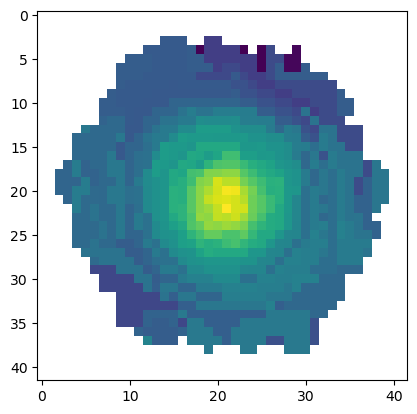

In [14]:
plt.imshow(ma.array(sMass, mask=sMass<1))

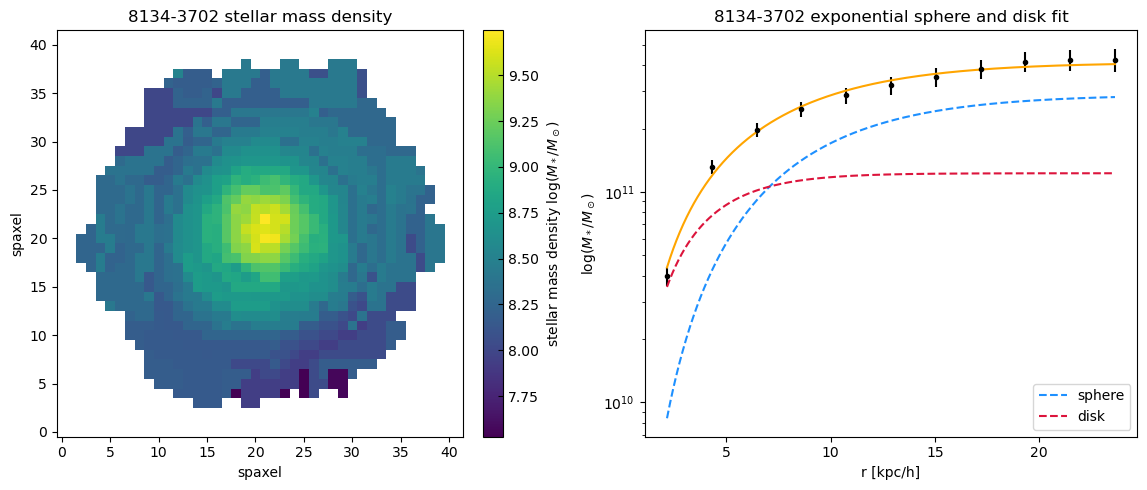

In [15]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

ax[0].invert_yaxis()
im2 = ax[0].imshow(ma.array(sMass, mask=sMass<1))
ax[0].invert_yaxis()
ax[0].set_xlabel('spaxel',  )
ax[0].set_ylabel('spaxel',  )
ax[0].set_title('8134-3702 stellar mass density')

cbar = plt.colorbar( im2, ax=ax[0], fraction=0.046, pad=0.04)
cbar.ax.tick_params( direction='in')

cbar.set_label(r'stellar mass density $\log(M_*/M_\odot)$')

ax[1].errorbar(mass_table['radius'], 10**mass_table['M_star'], yerr=10**mass_table['M_star_err'], color='k', fmt='.')
ax[1].plot(rs, sph, color='dodgerblue', linestyle='--', label='sphere')
ax[1].plot(rs, disk, color='crimson', linestyle='--', label='disk')
ax[1].plot(rs, sphdisk, color='orange')
ax[1].set_yscale('log')
ax[1].set_xlabel('r [kpc/h]',)
ax[1].set_ylabel(r'$\log(M_*/M_\odot)$',)
ax[1].legend(loc='lower right', )
ax[1].set_title('8134-3702 exponential sphere and disk fit')
fig.tight_layout()
fig.savefig(plot_dir + 'smass_sphd_fit.png', bbox_inches='tight')

## cmd

In [16]:
nsa_portsmouth = Table.read('/Users/nityaravi/Documents/Research/RotationCurves/data/NSA_v1_0_1_vflag_Portsmouth.fits')
nsa_portsmouth[:5]

IAUNAME,SUBDIR,RA,DEC,ISDSS,INED,ISIXDF,IALFALFA,IZCAT,ITWODF,MAG,Z,ZSRC,SIZE,RUN,CAMCOL,FIELD,RERUN,XPOS,YPOS,NSAID,ZDIST,SERSIC_NMGY,SERSIC_NMGY_IVAR,SERSIC_OK,SERSIC_RNMGY,SERSIC_ABSMAG,SERSIC_AMIVAR,EXTINCTION,SERSIC_KCORRECT,SERSIC_KCOEFF,SERSIC_MTOL,SERSIC_B300,SERSIC_B1000,SERSIC_METS,SERSIC_MASS,XCEN,YCEN,NPROF,PROFMEAN,PROFMEAN_IVAR,QSTOKES,USTOKES,BASTOKES,PHISTOKES,PETRO_FLUX,PETRO_FLUX_IVAR,FIBER_FLUX,FIBER_FLUX_IVAR,PETRO_BA50,PETRO_PHI50,PETRO_BA90,PETRO_PHI90,SERSIC_FLUX,SERSIC_FLUX_IVAR,SERSIC_N,SERSIC_BA,SERSIC_PHI,ASYMMETRY,CLUMPY,DFLAGS,AID,PID,DVERSION,PROFTHETA,PETRO_THETA,PETRO_TH50,PETRO_TH90,SERSIC_TH50,PLATE,FIBERID,MJD,RACAT,DECCAT,ZSDSSLINE,SURVEY,PROGRAMNAME,PLATEQUALITY,TILE,PLUG_RA,PLUG_DEC,ELPETRO_BA,ELPETRO_PHI,ELPETRO_FLUX_R,ELPETRO_FLUX_IVAR_R,ELPETRO_THETA_R,ELPETRO_TH50_R,ELPETRO_TH90_R,ELPETRO_THETA,ELPETRO_FLUX,ELPETRO_FLUX_IVAR,ELPETRO_TH50,ELPETRO_TH90,ELPETRO_APCORR_R,ELPETRO_APCORR,ELPETRO_APCORR_SELF,ELPETRO_NMGY,ELPETRO_NMGY_IVAR,ELPETRO_OK,ELPETRO_RNMGY,ELPETRO_ABSMAG,ELPETRO_AMIVAR,ELPETRO_KCORRECT,ELPETRO_KCOEFF,ELPETRO_MASS,ELPETRO_MTOL,ELPETRO_B300,ELPETRO_B1000,ELPETRO_METS,IN_DR7_LSS,u_r,g_r,NUV_r,index,imc,aimc,cd,conx1,u_r_KIAS,prmag,BPTclass,SFR,sSFR,HImass,vflag,u_r_err,g_r_err,NUV_r_err,ID,Flux_OII_3726,Flux_OII_3726_Err,AoN_OII_3726,Flux_OII_3728,Flux_OII_3728_Err,AoN_OII_3728,Flux_OIII_4363,Flux_OIII_4363_Err,AoN_OIII_4363,Flux_Hb_4861,Flux_Hb_4861_Err,AoN_Hb_4861,Flux_OIII_4958,Flux_OIII_4958_Err,Flux_OIII_5006,Flux_OIII_5006_Err,AoN_OIII_5006,Flux_NI_5197,Flux_NI_5197_Err,AoN_NI_5197,Flux_NI_5200,Flux_NI_5200_Err,AoN_NI_5200,Flux_OI_6300,Flux_OI_6300_Err,AoN_OI_6300,Flux_OI_6363,Flux_OI_6363_Err,AoN_OI_6363,Flux_NII_6547,Flux_NII_6547_Err,Flux_Ha_6562,Flux_Ha_6562_Err,AoN_Ha_6562,Flux_NII_6583,Flux_NII_6583_Err,AoN_NII_6583,Flux_SII_6716,Flux_SII_6716_Err,AoN_SII_6716,Flux_SII_6730,Flux_SII_6730_Err,AoN_SII_6730
bytes19,bytes27,float64,float64,int32,int32,int32,int32,int32,int32,float32,float32,bytes7,float32,int16,uint8,int16,bytes3,float32,float32,int32,float32,float32[7],float32[7],int16,float32[7],float32[7],float32[7],float32[7],float32[7],float32[5],float32[7],float32,float32,float32,float32,float64,float64,uint8[7],"float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]",float32[7],float32[7],float32[7],float32[7],float32,float32,float32,float32,float32[7],float32[7],float32,float32,float32,float32[7],float32[7],int32[7],int32,int32,bytes8,float32[15],float32,float32,float32,float32,int32,int16,int32,float64,float64,float32,bytes6,bytes27,bytes8,int32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32[7],float32[7],float32[7],float32[7],float32,float32[7],float32[7],float32[7],float32[7],int16,float32[7],float32[7],float32[7],float32[7],float32[5],float32,float32[7],float32,float32,float32,float64,float32,float32,float32,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
J023211.77+001326.5,02h/p00/J023211.77+001326.5,38.04906209256324,0.22402153989646575,39438,22721,-1,-1,71327,-1,16.771198,0.054021582,sdss,0.07,109,4,23,301,1960.5631,83.361275,38979,0.054392263,1.3420134 .. 884.58374,16.215242 .. 0.0016165179,1,1.4780203 .. 964.8986,-13.908231 .. -21.045618,24.77356 .. 1073.0248,0.2271526 .. 0.04052578,-0.060923357 .. 0.029009609,1.4557369e-05 .. 1.222673e-15,0.0016189957 .. 1.23927,2.5023096e-06,0.06656253,0.024689334,22540354000.0,156.48558044433594,201.36697387695312,10 .. 11,0.016490662 .. 0.0,5489.7393 .. 0.0,0.21582535 .. -0.09177922,0.0076095443 .. 0.15974313,0.64479166 ..

In [17]:
nsa_dict = {}
for i in range(len(nsa_portsmouth)):
    nsa_dict[nsa_portsmouth['NSAID'][i]] = i

In [18]:
cmd_dict = {1.0: 'b',
            2.0: 'g',
            3.0:'r',
            -99: 'k',
           -1: 'k'}

In [19]:
from matplotlib.lines import Line2D

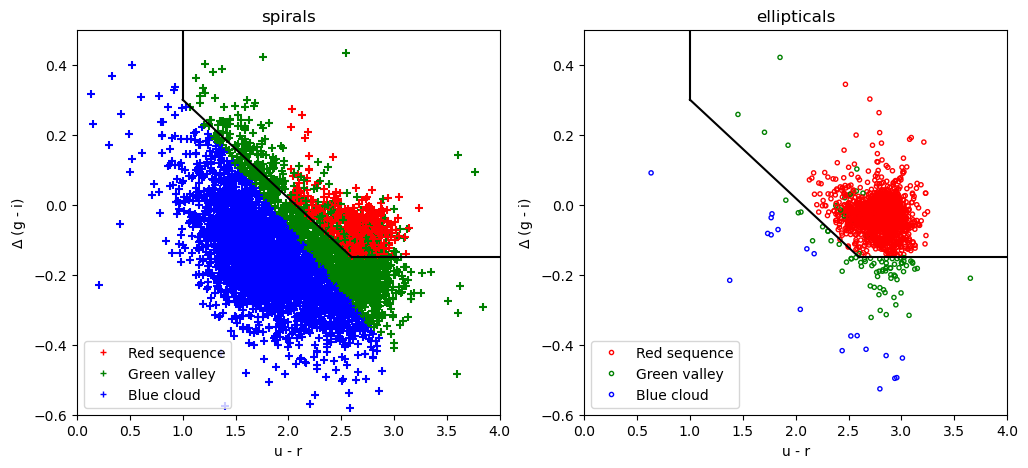

In [20]:
# g_count = 0
# r_count = 0
# b_count = 0
fig, ax = plt.subplots(1,2, figsize=(12,5))

for i in range(len(spirals)):
    nsaid = spirals[i]['nsa_nsaid']
    nsa_idx = nsa_dict[nsaid]

    ax[0].scatter(nsa_portsmouth['u_r_KIAS'][nsa_idx], nsa_portsmouth['cd'][nsa_idx], marker='+', color=cmd_dict[spirals[i]['CMD_class']],
               )

ax[0].set_xlim(0,4)
ax[0].set_ylim(-0.6,0.5)
ax[0].set_xlabel('u - r')
ax[0].set_ylabel(r'$\Delta$ (g - i)')
ax[0].plot([4,2.6],[-0.15,-0.15], color='k')
ax[0].plot([2.6,1.0],[-0.15,0.3], color='k')
ax[0].plot([1.0,1.0],[0.3,10], color='k')




legend_elements = [Line2D([0], [0], marker='+', color='w', label='Red sequence',
                          markeredgecolor='r', markersize=5),
                   Line2D([0], [0], marker='+', color='w', label='Green valley',
                          markeredgecolor='g', markersize=5),
                   Line2D([0], [0], marker='+', color='w', label='Blue cloud',
                          markeredgecolor='b', markersize=5)]


ax[0].legend(handles=legend_elements, loc='lower left')
ax[0].set_title('spirals')

for i in range(len(ellipticals)):
    nsaid = ellipticals[i]['nsa_nsaid']
    nsa_idx = nsa_dict[nsaid]

    ax[1].scatter(nsa_portsmouth['u_r_KIAS'][nsa_idx], nsa_portsmouth['cd'][nsa_idx], marker='.', color=cmd_dict[ellipticals[i]['CMD_class']],
               facecolor='none')
ax[1].set_xlim(0,4)
ax[1].set_ylim(-0.6,0.5)
ax[1].set_xlabel('u - r')
ax[1].set_ylabel(r'$\Delta$ (g - i)')
ax[1].plot([4,2.6],[-0.15,-0.15], color='k')
ax[1].plot([2.6,1.0],[-0.15,0.3], color='k')
ax[1].plot([1.0,1.0],[0.3,10], color='k')




legend_elements = [Line2D([0], [0], marker='o', color='w', label='Red sequence',
                          markeredgecolor='r', markersize=3),
                   Line2D([0], [0], marker='o', color='w', label='Green valley',
                          markeredgecolor='g', markersize=3),
                   Line2D([0], [0], marker='o', color='w', label='Blue cloud',
                          markeredgecolor='b', markersize=3)]


ax[1].legend(handles=legend_elements, loc='lower left')
ax[1].set_title('ellipticals')
plt.savefig(plot_dir + 'CMD.png', bbox_inches='tight')

## Mr vs Mstar

In [21]:
bins = np.linspace(np.min([np.min(spirals['rabsmag']), np.min(ellipticals['rabsmag'])]),
                  np.max([np.max(spirals['rabsmag']), np.max(ellipticals['rabsmag'])]), 15)
pts = (bins[:-1] + bins [1:]) / 2

e_mstar = []
s_mstar = []


# xp = [-23,-16]
# fp = [13, 10.5]
# rm_outliers = ellipticals[ellipticals['sphd_M_star'] < np.interp(ellipticals['rabsmag'],xp,fp)]

for i in range(len(pts)):
    mag_lim = bins[i+1]
    if i == 0:
        e_mstar.append(ellipticals['e_Mstar_R90'][ellipticals['rabsmag'] <= mag_lim])
        s_mstar.append(spirals['M90_disk'][spirals['rabsmag'] <= mag_lim])
        
    else:
        lower_lim = bins[i]
        e_mstar.append(ellipticals['e_Mstar_R90'][np.logical_and(ellipticals['rabsmag'] <= mag_lim, 
                                                                         ellipticals['rabsmag'] > lower_lim)])
        
        s_mstar.append(spirals['M90_disk'][np.logical_and(spirals['rabsmag'] <= mag_lim, 
                                                                         spirals['rabsmag'] > lower_lim)])

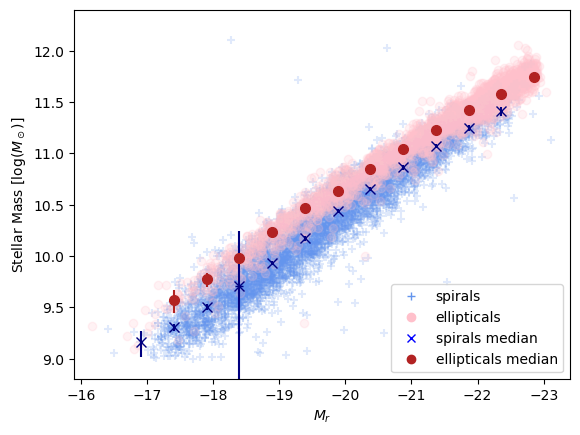

In [22]:
plt.scatter(spirals['rabsmag'], spirals['M90_disk'], marker='+', color='cornflowerblue', alpha=0.2, label='spirals')
plt.scatter(ellipticals['rabsmag'], ellipticals['e_Mstar_R90'], color='pink', marker='o', alpha=0.2, label='ellipticals')
plt.xlim(-15.9, -23.4)
plt.ylim(8.8,12.4)
plt.xlabel(r'$M_r$')
plt.ylabel(r'Stellar Mass $[\log(M_\odot)]$')

legend_elements = [Line2D([0], [0], marker='+', color='w', label='spirals',
                          markeredgecolor='cornflowerblue', markersize=6),
                   Line2D([0], [0], marker='o', color='w', label='ellipticals',
                          markeredgecolor='pink', markerfacecolor='pink', markersize=6),
                   Line2D([0], [0], marker='x', color='w', label='spirals median',
                          markeredgecolor='b', markerfacecolor='b', markersize=6),
                   Line2D([0], [0], marker='o', color='w', label='ellipticals median',
                          markeredgecolor='firebrick', markerfacecolor='firebrick', markersize=6)


                  ]

ep_mstar = med_err(e_mstar)
inf_bars = np.where(ep_mstar == np.inf)[0]
ep_mstar[inf_bars][:,0]

plt.errorbar(pts, ep_mstar[:,0], color='firebrick', yerr=[ep_mstar[:,1] ,ep_mstar[:,2]], 
             marker='o', label='elliptical median',linestyle='none', markersize=7, )
plt.errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], 
             yerr=ep_mstar[inf_bars][:,0], 
             uplims=True,
             color='firebrick', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mstar[inf_bars][:,2]],
                linestyle='none', color='firebrick', mfc='none', mec='none')


ep_mstar = med_err(s_mstar)
inf_bars = np.where(ep_mstar == np.inf)[0]
ep_mstar[inf_bars][:,0]

plt.errorbar(pts, ep_mstar[:,0], color='navy', yerr=[ep_mstar[:,1] ,ep_mstar[:,2]], 
                 marker='x', label='spiral median',linestyle='none', markersize=7,)
plt.errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], 
             yerr=ep_mstar[inf_bars][:,0], 
             uplims=True,
             color='navy', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mstar[inf_bars][:,2]],
            linestyle='none', color='navy', mfc='none', mec='none')


plt.legend(handles=legend_elements, loc='lower right')
plt.savefig(plot_dir + 'mstar_mr_all.png')

## Mr vs. Mstar by color

In [282]:
# def samples
blue_spirals = spirals[spirals['CMD_class']==1]
green_spirals = spirals[spirals['CMD_class']==2]
red_spirals = spirals[spirals['CMD_class']==3]

In [283]:
bins = np.linspace(np.min([np.min(spirals['rabsmag']), np.min(ellipticals['rabsmag'])]),
                  np.max([np.max(spirals['rabsmag']), np.max(ellipticals['rabsmag'])]), 15)
pts = (bins[:-1] + bins [1:]) / 2

e_mstar = []
b_s_mstar = []
g_s_mstar = []
r_s_mstar = []


xp = [-23,-16]
fp = [13, 10.5]
rm_outliers = ellipticals[ellipticals['e_Mstar_R90'] < np.interp(ellipticals['rabsmag'],xp,fp)]

for i in range(len(pts)):
    mag_lim = bins[i+1]
    if i == 0:
        e_mstar.append(rm_outliers['e_Mstar_R90'][rm_outliers['rabsmag'] <= mag_lim])
        r_s_mstar.append(red_spirals['M90_disk'][red_spirals['rabsmag'] <= mag_lim])
        b_s_mstar.append(blue_spirals['M90_disk'][blue_spirals['rabsmag'] <= mag_lim])
        g_s_mstar.append(green_spirals['M90_disk'][green_spirals['rabsmag'] <= mag_lim])

    else:
        lower_lim = bins[i]
        e_mstar.append(rm_outliers['e_Mstar_R90'][np.logical_and(rm_outliers['rabsmag'] <= mag_lim, 
                                                                         rm_outliers['rabsmag'] > lower_lim)])
        
        r_s_mstar.append(red_spirals['M90_disk'][np.logical_and(red_spirals['rabsmag'] <= mag_lim, 
                                                                         red_spirals['rabsmag'] > lower_lim)])
        b_s_mstar.append(blue_spirals['M90_disk'][np.logical_and(blue_spirals['rabsmag'] <= mag_lim, 
                                                                         blue_spirals['rabsmag'] > lower_lim)])
        g_s_mstar.append(green_spirals['M90_disk'][np.logical_and(green_spirals['rabsmag'] <= mag_lim, 
                                                                         green_spirals['rabsmag'] > lower_lim)])


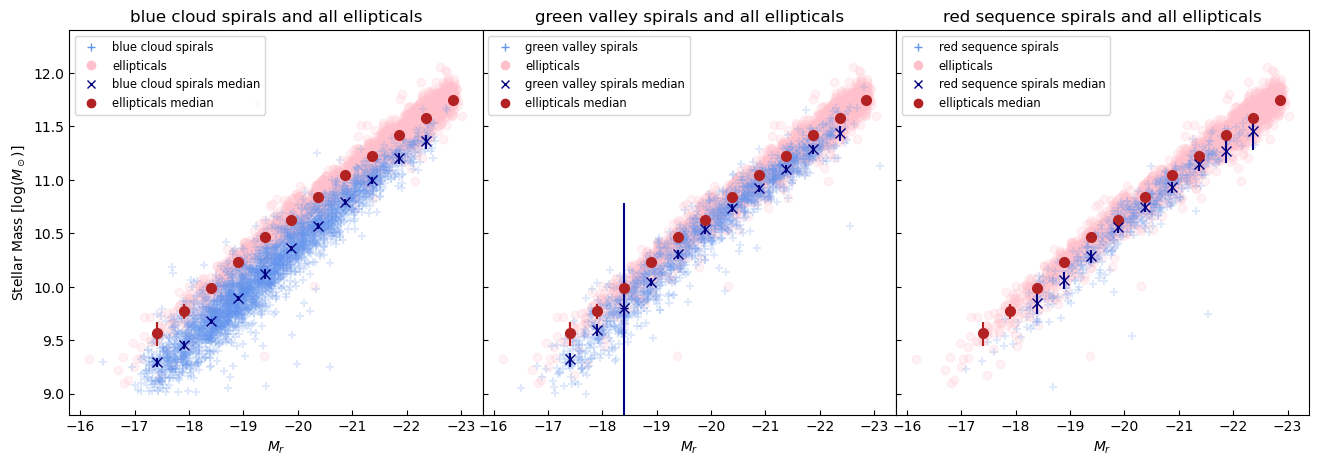

In [284]:
fig, ax = plt.subplots(1,3, figsize=(16,5), sharey=True)
fig.subplots_adjust(wspace=0)


ax[0].scatter(ellipticals['rabsmag'], ellipticals['e_Mstar_R90'], color='pink', marker='o', alpha=0.2, label='ellipticals')
ax[0].scatter(blue_spirals['rabsmag'], blue_spirals['M90_disk'], color='cornflowerblue', marker='+', alpha=0.2, label='blue cloud spirals')
ax[0].set_xlim(-15.8, -23.4)
ax[0].set_ylim(8.8, 12.4)
ax[0].set_title('blue cloud spirals and all ellipticals')
ax[0].set_xlabel(r'$M_r$')
ax[0].set_ylabel(r'Stellar Mass $[\log(M_\odot)]$')


ax[1].scatter(ellipticals['rabsmag'], ellipticals['e_Mstar_R90'], color='pink', marker='o', alpha=0.2, label='ellipticals')
ax[1].scatter(green_spirals['rabsmag'], green_spirals['M90_disk'], color='cornflowerblue', marker='+', alpha=0.2, label='green valley spirals')
ax[1].set_xlim(-15.8, -23.4)
ax[1].set_ylim(8.8, 12.4)
ax[1].set_title('green valley spirals and all ellipticals')
ax[1].set_xlabel(r'$M_r$')



ax[2].scatter(ellipticals['rabsmag'], ellipticals['e_Mstar_R90'], color='pink', marker='o', alpha=0.2, label='ellipticals')
ax[2].scatter(red_spirals['rabsmag'], red_spirals['M90_disk'], color='cornflowerblue', marker='+', alpha=0.2, label='red sequence spirals')
ax[2].set_xlim(-15.8, -23.4)
ax[2].set_ylim(8.8, 12.4)
ax[2].set_title('red sequence spirals and all ellipticals')
ax[2].set_xlabel(r'$M_r$')

ax[0].tick_params( axis='both', direction='in')
ax[1].tick_params( axis='both', direction='in')
ax[2].tick_params( axis='both', direction='in')


ep_mstar = med_err(e_mstar)
inf_bars = np.where(ep_mstar == np.inf)[0]
ep_mstar[inf_bars][:,0]

for i in range(3):
    ax[i].errorbar(pts, ep_mstar[:,0], color='firebrick', yerr=[ep_mstar[:,1] ,ep_mstar[:,2]], 
                 marker='o', label='elliptical median',linestyle='none', markersize=7, )
    ax[i].errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], 
                 yerr=ep_mstar[inf_bars][:,0], 
                 uplims=True,
                 color='firebrick', linestyle='none', capsize=3, mfc='none', mec='none')
    ax[i].errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mstar[inf_bars][:,2]],
                linestyle='none', color='firebrick', mfc='none', mec='none')



ep_mstar = med_err(b_s_mstar)
inf_bars = np.where(ep_mstar == np.inf)[0]
ep_mstar[inf_bars][:,0]

ax[0].errorbar(pts, ep_mstar[:,0], color='navy', yerr=[ep_mstar[:,1] ,ep_mstar[:,2]], 
                 marker='x', label='blue cloud spiral median',linestyle='none', markersize=7,)
ax[0].errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], 
             yerr=ep_mstar[inf_bars][:,0], 
             uplims=True,
             color='navy', linestyle='none', capsize=3, mfc='none', mec='none')
ax[0].errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mstar[inf_bars][:,2]],
            linestyle='none', color='navy', mfc='none', mec='none')

ep_mstar = med_err(g_s_mstar)
inf_bars = np.where(ep_mstar == np.inf)[0]
ep_mstar[inf_bars][:,0]

ax[1].errorbar(pts, ep_mstar[:,0], color='navy', yerr=[ep_mstar[:,1] ,ep_mstar[:,2]], 
                 marker='x', label='green valley spiral median',linestyle='none', markersize=7,)
ax[1].errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], 
             yerr=ep_mstar[inf_bars][:,0], 
             uplims=True,
             color='navy', linestyle='none', capsize=3, mfc='none', mec='none')
ax[1].errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mstar[inf_bars][:,2]],
            linestyle='none', color='navy', mfc='none', mec='none')

ep_mstar = med_err(r_s_mstar)
inf_bars = np.where(ep_mstar == np.inf)[0]
ep_mstar[inf_bars][:,0]

ax[2].errorbar(pts, ep_mstar[:,0], color='navy', yerr=[ep_mstar[:,1] ,ep_mstar[:,2]], 
                 marker='x', label='red sequence spiral median',linestyle='none', markersize=7,)
ax[2].errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], 
             yerr=ep_mstar[inf_bars][:,0], 
             uplims=True,
             color='navy', linestyle='none', capsize=3, mfc='none', mec='none')
ax[2].errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mstar[inf_bars][:,2]],
            linestyle='none', color='navy', mfc='none', mec='none')

legend_elements = [Line2D([0], [0], marker='+', color='w', label='blue cloud spirals',
                          markeredgecolor='cornflowerblue', markersize=6),
                   Line2D([0], [0], marker='o', color='w', label='ellipticals',
                          markeredgecolor='pink', markerfacecolor='pink', markersize=6),
                  
                   Line2D([0], [0], marker='x', color='w', label='blue cloud spirals median',
                          markeredgecolor='navy', markerfacecolor='navy', markersize=6),
                  
                   Line2D([0], [0], marker='o', color='w', label='ellipticals median',
                          markeredgecolor='firebrick', markerfacecolor='firebrick', markersize=6)]


ax[0].legend(handles=legend_elements, fontsize='small')
legend_elements = [Line2D([0], [0], marker='+', color='w', label='green valley spirals',
                          markeredgecolor='cornflowerblue', markersize=6),
                   Line2D([0], [0], marker='o', color='w', label='ellipticals',
                          markeredgecolor='pink', markerfacecolor='pink', markersize=6),
                  
                   Line2D([0], [0], marker='x', color='w', label='green valley spirals median',
                          markeredgecolor='navy', markerfacecolor='navy', markersize=6),
                  
                   Line2D([0], [0], marker='o', color='w', label='ellipticals median',
                          markeredgecolor='firebrick', markerfacecolor='firebrick', markersize=6)]


ax[1].legend(handles=legend_elements, fontsize='small')
legend_elements = [Line2D([0], [0], marker='+', color='w', label='red sequence spirals',
                          markeredgecolor='cornflowerblue', markersize=6),
                   Line2D([0], [0], marker='o', color='w', label='ellipticals',
                          markeredgecolor='pink', markerfacecolor='pink', markersize=6),
                  
                   Line2D([0], [0], marker='x', color='w', label='red sequence spirals median',
                          markeredgecolor='navy', markerfacecolor='navy', markersize=6),
                  
                   Line2D([0], [0], marker='o', color='w', label='ellipticals median',
                          markeredgecolor='firebrick', markerfacecolor='firebrick', markersize=6)]
ax[2].legend(handles=legend_elements, fontsize='small')

plt.savefig(plot_dir + 'mr_mstar_cmd.png', bbox_inches='tight')

## mstar map vs nsa

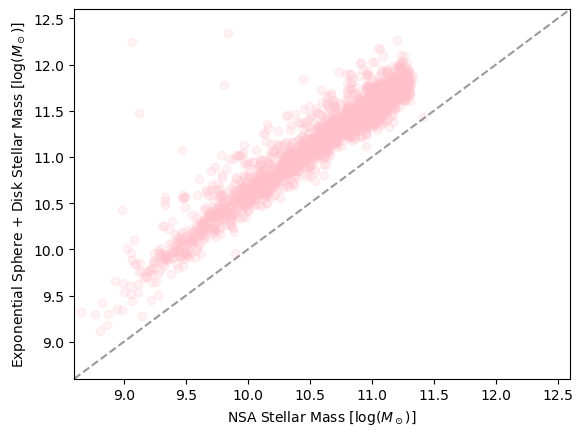

In [239]:
plt.scatter(np.log10(ellipticals['nsa_elpetro_mass']), ellipticals['sphd_M_star'], marker='o', color='pink', alpha=0.2)
plt.xlim(8.6,12.6)
plt.ylim(8.6,12.6)
plt.plot([8.6,13],[8.6,13], color='k', linestyle='--', alpha=0.4)
plt.xlabel(r'NSA Stellar Mass $[\log(M_\odot)]$')
plt.ylabel(r'Exponential Sphere + Disk Stellar Mass $[\log(M_\odot)]$')
plt.savefig(plot_dir + 'elliptical_mass_compare.png', bbox_inches='tight')

## mtot & mvir comparison, mvir vs mstar

In [259]:
bins = np.linspace(np.min([np.min(spirals['rabsmag']), np.min(ellipticals['rabsmag'])]),
                  np.max([np.max(spirals['rabsmag']), np.max(ellipticals['rabsmag'])]), 15)
pts = (bins[:-1] + bins [1:]) / 2

e_mstar = []
s_mstar = []


# xp = [-23,-16]
# fp = [13, 10.5]
# rm_outliers = ellipticals[ellipticals['sphd_M_star'] < np.interp(ellipticals['rabsmag'],xp,fp)]

for i in range(len(pts)):
    mag_lim = bins[i+1]
    if i == 0:
        e_mstar.append(ellipticals['Mvir'][ellipticals['rabsmag'] <= mag_lim])
        s_mstar.append(spirals['M_R90'][spirals['rabsmag'] <= mag_lim])
        
    else:
        lower_lim = bins[i]
        e_mstar.append(ellipticals['Mvir'][np.logical_and(ellipticals['rabsmag'] <= mag_lim, 
                                                                         ellipticals['rabsmag'] > lower_lim)])
        
        s_mstar.append(spirals['M_R90'][np.logical_and(spirals['rabsmag'] <= mag_lim, 
                                                                         spirals['rabsmag'] > lower_lim)])


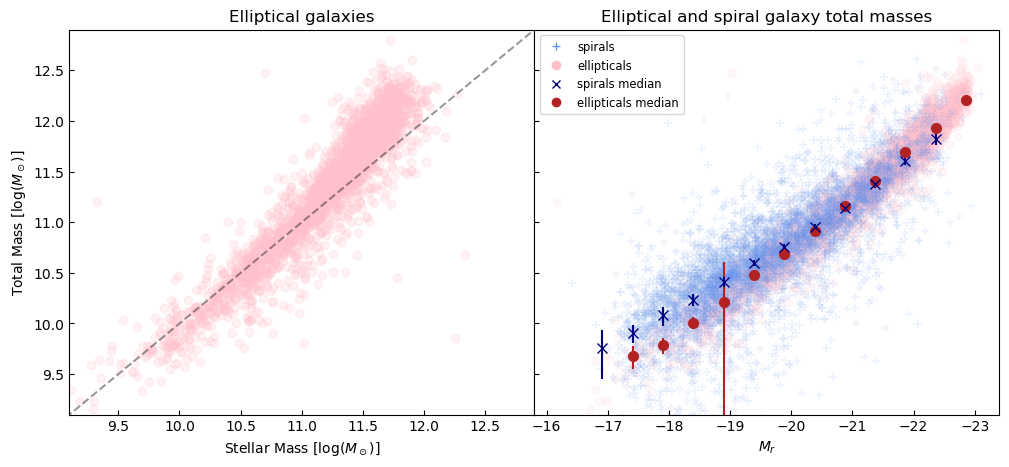

In [264]:
fig, ax = plt.subplots(1,2, figsize=(12,5), sharey=True)
fig.subplots_adjust(wspace=0)

ax[0].scatter(ellipticals['sphd_M_star'], ellipticals['Mvir'], color='pink', alpha=0.2)
ax[0].set_xlabel(r'Stellar Mass $[\log(M_\odot)]$')
ax[0].set_ylabel(r'Total Mass $[\log(M_\odot)]$')
ax[0].set_xlim(9.1,12.9)
ax[0].set_ylim(9.1,12.9)
ax[0].plot([9,14],[9,14], color='k', linestyle='--', alpha=0.4)
ax[0].set_title('Elliptical galaxies')

ax[1].scatter(ellipticals['rabsmag'], ellipticals['Mvir'], color='pink', alpha=0.1, label='ellipticals')
ax[1].scatter(spirals['rabsmag'], spirals['M_R90'], color='cornflowerblue', alpha=0.1, label='spirals', marker='+')


ax[1].set_xlabel(r'$M_r$')
ax[1].set_xlim(-15.8,-23.4)
# ax[0].plot([9,14],[9,14], color='k', linestyle='--', alpha=0.4)
ax[1].set_title('Elliptical and spiral galaxy total masses')
ax[0].tick_params( axis='both', direction='in')
ax[1].tick_params( axis='both', direction='in')


ep_mstar = med_err(e_mstar)
inf_bars = np.where(ep_mstar == np.inf)[0]
ep_mstar[inf_bars][:,0]

ax[1].errorbar(pts, ep_mstar[:,0], color='firebrick', yerr=[ep_mstar[:,1] ,ep_mstar[:,2]], 
             marker='o', label='elliptical median',linestyle='none', markersize=7, )
ax[1].errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], 
             yerr=ep_mstar[inf_bars][:,0], 
             uplims=True,
             color='firebrick', linestyle='none', capsize=3, mfc='none', mec='none')
ax[1].errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mstar[inf_bars][:,2]],
                linestyle='none', color='firebrick', mfc='none', mec='none')


ep_mstar = med_err(s_mstar)
inf_bars = np.where(ep_mstar == np.inf)[0]
ep_mstar[inf_bars][:,0]

ax[1].errorbar(pts, ep_mstar[:,0], color='navy', yerr=[ep_mstar[:,1] ,ep_mstar[:,2]], 
                 marker='x', label='spiral median',linestyle='none', markersize=7,)
ax[1].errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], 
             yerr=ep_mstar[inf_bars][:,0], 
             uplims=True,
             color='navy', linestyle='none', capsize=3, mfc='none', mec='none')
ax[1].errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mstar[inf_bars][:,2]],
            linestyle='none', color='navy', mfc='none', mec='none')


legend_elements = [Line2D([0], [0], marker='+', color='w', label='spirals',
                          markeredgecolor='cornflowerblue', markersize=6),
                   Line2D([0], [0], marker='o', color='w', label='ellipticals',
                          markeredgecolor='pink', markerfacecolor='pink', markersize=6),
                  
                   Line2D([0], [0], marker='x', color='w', label='spirals median',
                          markeredgecolor='navy', markerfacecolor='navy', markersize=6),
                  
                   Line2D([0], [0], marker='o', color='w', label='ellipticals median',
                          markeredgecolor='firebrick', markerfacecolor='firebrick', markersize=6)]


ax[1].legend(handles=legend_elements, fontsize='small')

fig.savefig(plot_dir + 'ellipticals_mtot_compare.png')